# Full Bayesian Operator Inference: FitzHugh-Nagumo

**Workflow:**
1. Generate training data and fit POD basis
2. Grid search for prior operator
3. Fit GP hyperparameters
4. Run Bayesian inference (SVI/MCMC)
5. Evaluate and visualize results

## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    grid_search_prior_operator,
    fit_gp_hyperparameters_mle,
    compute_gp_derivatives,
    build_bayesian_opinf_model,
    run_svi,
    run_mcmc,
    generate_rom_predictions,
    plot_deterministic_rom_solves,
    plot_gp_fit,
    plot_full_order_error,
    Plotter,
    run_diagnostics,
    DataScaler,
)
import config
from config import Basis, ReducedOrderModel
from fitz_plotter import FitzPlotter

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAHBN"       # OpInf operator structure (with inputs)
NUM_MODES = 3             # POD modes to retain

# Data generation settings
TRAINING_SPAN = (0, 3.0)  # Subset of time domain for training
PREDICTION_SPAN = (0, 5.0) # Full time domain for ROM evaluation
NUM_SAMPLES = 600          # Number of training samples
NOISE_LEVEL = 0.01        # Noise level for training data
NUM_EVAL_POINTS = None    # Set to None for no densification

# Data scaling
USE_SCALED_DATA = True    # Standardize POD coefficients for GP fitting

# Inference settings
RUN_SVI = True
RUN_MCMC = True           # More expensive, optional
USE_SVI_FOR_MCMC_INIT = True  # Initialize MCMC from SVI result
USE_SHIFTED_PRIOR_FOR_MCMC = True  # Rebuild model with prior shifted to SVI posterior for MCMC
USE_DETERMINISTIC_PRIOR = True  # Use deterministic OpInf solve as prior mean for SVI
GUIDE = numpyro.infer.autoguide.AutoDelta  # Guide for SVI
# GUIDE = numpyro.infer.autoguide.AutoNormal
VERBOSE = True             # Show progress bars (set False for papermill runs)

# Hyperparameters
GAMMA = 1e0     # Operator prior variance
GAMMA2 = 1e0    # ODE constraint stiffness
GAMMA3 = 1e-1    # Operator prior variance for MCMC (if different from SVI)
GAMMA4 = 1e-1    # ODE constraint stiffness for MCMC (if different from SVI)

## 2. Generate Training Data

In [3]:
# Generate training data using the standard pipeline
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, np.linspace(*PREDICTION_SPAN, 801), TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

# Input function
input_func = ReducedOrderModel.input_func
inputs_sampled = np.array(input_func(time_sampled))

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Sampled snapshots: {snapshots_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

generating training data...done in 0.25 s.
Full time domain: (801,)
True states: (1024, 801)
Sampled times: (600,)
Sampled snapshots: (1024, 600)
Training span: [0.0000, 3.0000]
Prediction span: [0.0000, 5.0000]


In [4]:
# Fit POD basis
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
full_states_compressed = basis.compress(true_states)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

Compressed shape: (3, 600)
Cumulative energy: 99.9006%


In [ ]:
# Set up evaluation time domains for plotting
NUM_REGRESSION_POINTS = 150
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)

print(f"Training samples: {time_sampled.shape[0]}")
print(f"Eval training domain: [{time_domain_eval_training[0]:.4f}, {time_domain_eval_training[-1]:.4f}] ({len(time_domain_eval_training)} pts)")
print(f"Eval prediction domain: [{time_domain_eval_prediction[0]:.4f}, {time_domain_eval_prediction[-1]:.4f}] ({len(time_domain_eval_prediction)} pts)")

Training samples: 600
Eval training domain: [0.0000, 3.0000] (150 pts)
Eval prediction domain: [0.0000, 5.0000] (150 pts)


## 3a. Data Scaling (Optional)

In [ ]:
# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

Scaling enabled: DataScaler(num_modes=3, fitted=True, mean_range=[-5.995e-01, 1.434e+01], std_range=[1.449e+00, 1.211e+01])


## 3. Grid Search for Prior Operator

In [7]:
# Find best deterministic operator via regularization grid search
result = grid_search_prior_operator(
    basis=basis,
    time_domain_sampled=time_sampled,
    snapshots_sampled=snapshots_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=inputs_sampled.T if inputs_sampled.ndim > 1 else inputs_sampled[:, None].T,
    input_func=input_func,
    verbose=VERBOSE
)

prior_operator = result.operator
rom = result.rom
print(f"\nPrior operator shape: {prior_operator.shape}")

Grid search: testing 81 regularization values...
  reg=1.0e-16: STABLE, error=0.481273
  reg=1.8e-16: STABLE, error=0.481273
  reg=3.2e-16: STABLE, error=0.481273
  reg=5.6e-16: STABLE, error=0.481273
  reg=1.0e-15: STABLE, error=0.481273
  reg=1.8e-15: STABLE, error=0.481273
  reg=3.2e-15: STABLE, error=0.481273
  reg=5.6e-15: STABLE, error=0.481273
  reg=1.0e-14: STABLE, error=0.481273
  reg=1.8e-14: STABLE, error=0.481273
  reg=3.2e-14: STABLE, error=0.481273
  reg=5.6e-14: STABLE, error=0.481273
  reg=1.0e-13: STABLE, error=0.481273
  reg=1.8e-13: STABLE, error=0.481273
  reg=3.2e-13: STABLE, error=0.481273
  reg=5.6e-13: STABLE, error=0.481273
  reg=1.0e-12: STABLE, error=0.481273
  reg=1.8e-12: STABLE, error=0.481273
  reg=3.2e-12: STABLE, error=0.481273
  reg=5.6e-12: STABLE, error=0.481273
  reg=1.0e-11: STABLE, error=0.481273
  reg=1.8e-11: STABLE, error=0.481273
  reg=3.2e-11: STABLE, error=0.481273
  reg=5.6e-11: STABLE, error=0.481273
  reg=1.0e-10: STABLE, error=0.481273
 

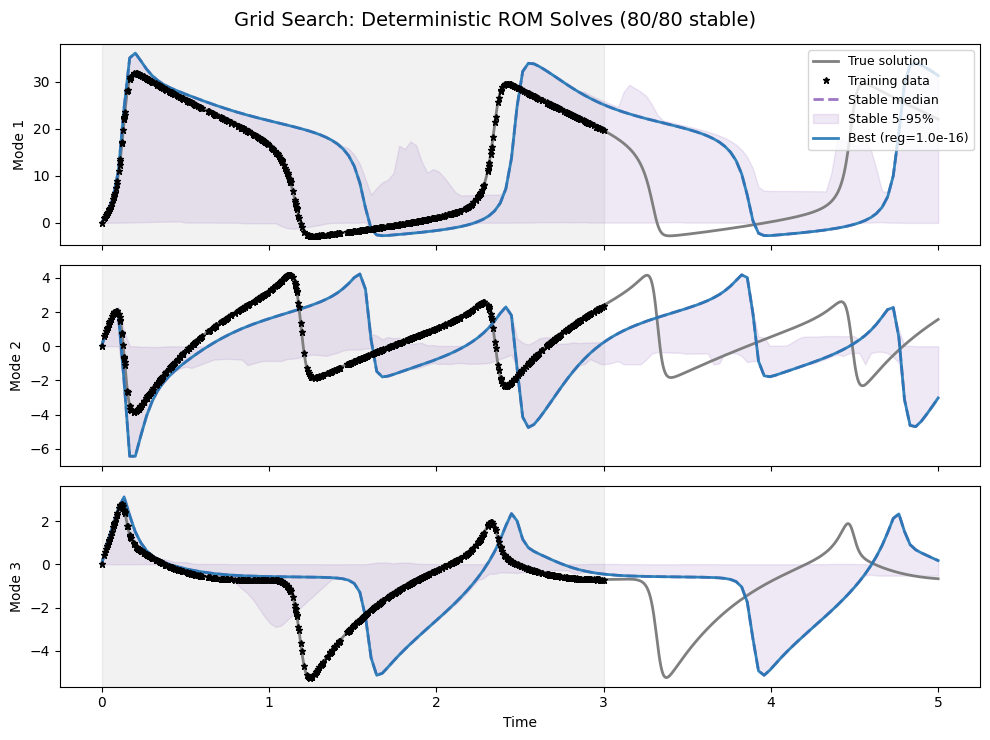

In [8]:
# Plot all stable deterministic ROM solves from grid search
from fitz_plotter import plot_fitz_grid_search

fig, axes = plot_fitz_grid_search(
    grid_search_result=result,
    snapshots_compressed=snapshots_comp_sampled,
    time_sampled=time_sampled,
    time_eval_training=time_domain_eval_training,
    time_eval_prediction=time_domain_eval_prediction,
    num_modes=NUM_MODES,
    input_func=input_func,
    time_full=time_domain_full,
    true_states_compressed=full_states_compressed,
    training_span=TRAINING_SPAN,
)
plt.show()

## 4. Fit GP Hyperparameters

In [9]:
# Start time of the full algorithm
import time

start_time = time.time()
total_plot_time = 0

In [10]:
# Fit GP for each mode via MLE (on scaled data if enabled)
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=VERBOSE
)

Fitting GP hyperparameters via MLE...
  L=0.0463, V=0.3953, N=0.000001
  Mode 0: L=0.0463, V=0.3953, N=0.000001
  L=0.0409, V=0.4437, N=0.000009
  Mode 1: L=0.0409, V=0.4437, N=0.000009
  L=0.0411, V=0.4438, N=0.000003
  Mode 2: L=0.0411, V=0.4438, N=0.000003


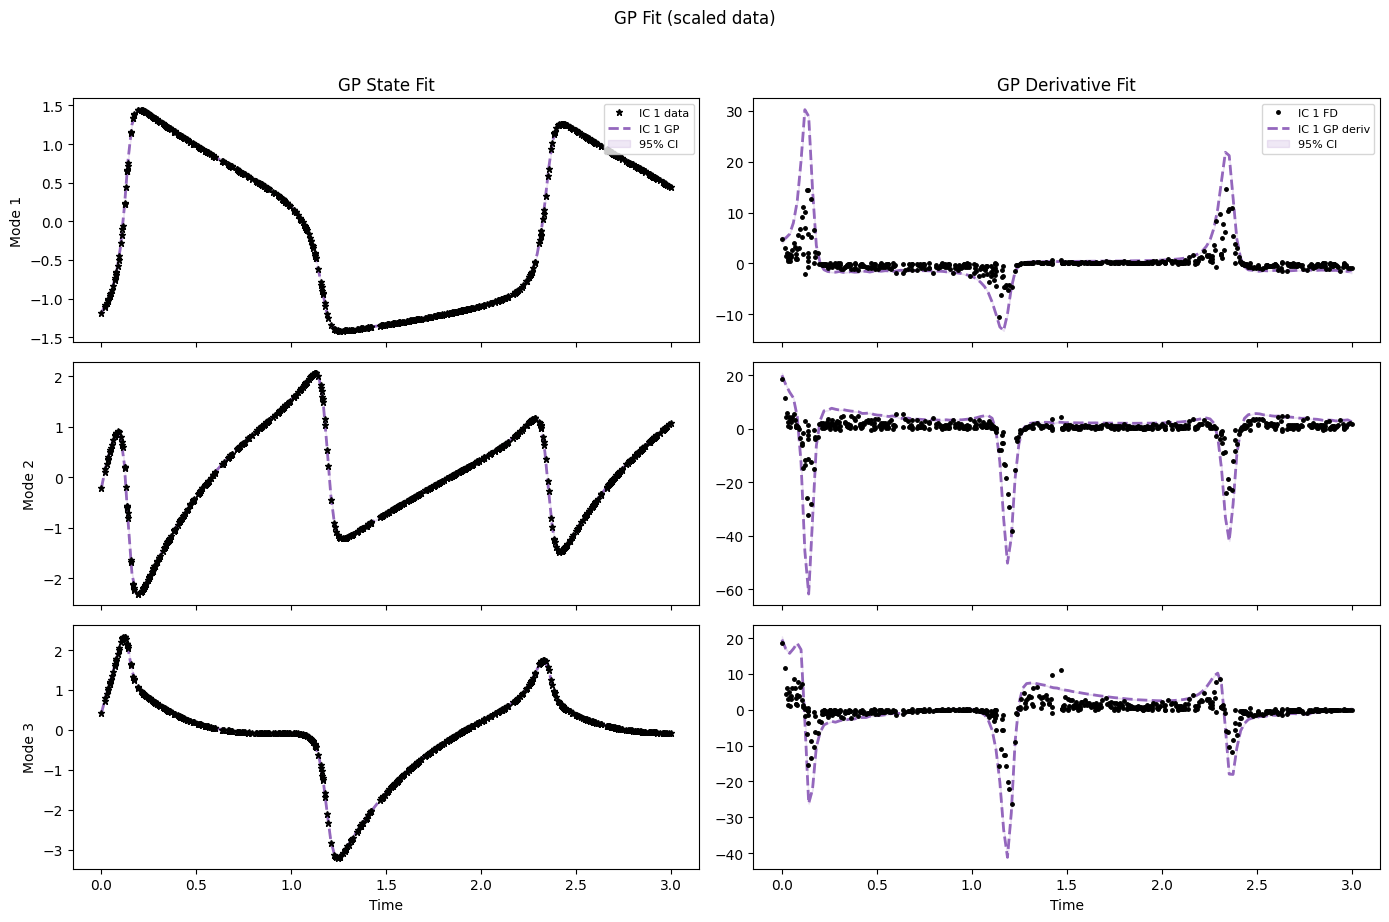

In [11]:
# Visualize GP fit quality (states and derivatives)
# Note: GP models were fitted on training_data (scaled if USE_SCALED_DATA)
_plot_t0 = time.time()
fig, axes = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=training_data,
    time_sampled=time_sampled,
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
)
plt.suptitle(f"GP Fit ({'scaled' if USE_SCALED_DATA else 'unscaled'} data)", y=1.02)
plt.show()
total_plot_time += time.time() - _plot_t0

## 5. Bayesian Inference

In [12]:
# Build evaluation time grid (densified via GP if NUM_EVAL_POINTS is set)
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(time_sampled[0], time_sampled[-1], NUM_EVAL_POINTS)
    print(f"GP densification: evaluating ODE constraints at {NUM_EVAL_POINTS} points "
          f"(vs {len(time_sampled)} training samples)")
else:
    time_eval = time_sampled
    print(f"No densification: evaluating at {len(time_sampled)} training times")

# Precompute GP mean predictions at evaluation points
Xs_means = np.array([
    gp_models[i].predict(time_eval[:, None], return_std=False)
    for i in range(NUM_MODES)
])
inputs_eval = np.array(input_func(time_eval)).T

# Build Bayesian model using shared factory function
bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=prior_operator if USE_DETERMINISTIC_PRIOR else jnp.zeros_like(prior_operator),
    rom=rom,
    Ls_means=Ls,
    Vs_means=Vs,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    Xs_means=Xs_means,
    Ns_means=Ns,
    inputs_eval=inputs_eval,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
)
print("Bayesian model built")

No densification: evaluating at 600 training times
Bayesian model built


Running SVI (gamma=1.0, gamma2=1.0)...


100%|██████████| 30000/30000 [06:13<00:00, 80.31it/s, init loss: 687855.5625, avg. loss [28501-30000]: 2764.0791]


✅ SVI complete! Final loss: 2750.4719
   Sample keys: ['O', 'X0_0', 'X0_1', 'X0_2']
SVI operator extracted from key 'O', shape: (3, 14)


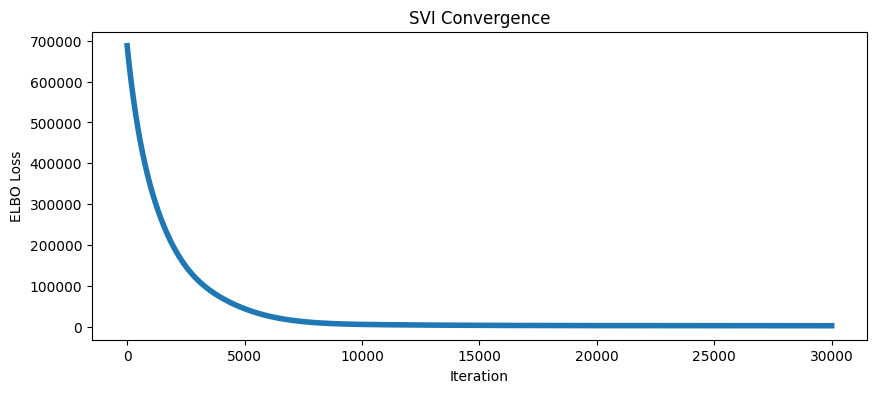

In [13]:
# Run SVI
if RUN_SVI:
    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=30000,
        # num_steps=100000,
        learning_rate=1e-4,
        # learning_rate=1e-5,
        verbose=VERBOSE,
        guide=GUIDE
    )
    samples = svi_result.samples
    
    # Extract operator for potential MCMC initialization
    # AutoDelta stores as 'O_auto_loc', MCMC stores as 'O'
    O_key = next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        # Get point estimate (mean over samples or first sample)
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")
    
    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

### 5a. SVI Results

In [14]:
import importlib, fitz_plotter
importlib.reload(fitz_plotter)
from fitz_plotter import FitzPlotter

def _evaluate_and_plot(stage_samples, stage_name):
    """Generate predictions and plots for a given inference stage."""
    Os_stage, Xs_stage, rom_solves_stage = generate_rom_predictions(
        samples=stage_samples, rom=rom,
        snapshots_compressed=snapshots_comp_sampled,
        time_eval=time_domain_eval_prediction,
        num_modes=NUM_MODES, num_pulls=200,
        input_func=input_func,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
    )
    print(f"[{stage_name}] Operator samples: {len(Os_stage)}, "
          f"Stable solves: {len(rom_solves_stage)}")

    # Operator posterior summary
    O_mean_stage = Os_stage.mean(axis=0)
    O_std_stage = Os_stage.std(axis=0)
    print(f"\n{stage_name} Posterior mean (first row): {O_mean_stage[0, :5]}")
    print(f"{stage_name} Posterior std  (first row): {O_std_stage[0, :5]}")

    # Get latent state samples and inverse-transform if scaled
    latent_state_samples = []
    for i in range(NUM_MODES):
        key_multi = f'X0_{i}'
        key_legacy = f'X{i}'
        key = key_multi if key_multi in stage_samples else key_legacy
        if key in stage_samples:
            Xi = stage_samples[key]
            if USE_SCALED_DATA and data_scaler is not None:
                Xi = np.array(Xi) * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
            latent_state_samples.append(Xi)
        else:
            latent_state_samples.append(np.tile(snapshots_comp_sampled[i], (len(Os_stage), 1)))

    # State reconstruction using FitzPlotter
    plotter_stage = FitzPlotter(
        numPODmodes=NUM_MODES,
        time_domain_training=time_sampled,
        time_domain_prediction=time_domain_full,
        time_domain_eval_training=time_domain_eval_training,
        time_domain_eval_prediction=time_domain_eval_prediction,
        snapshots_training=snapshots_comp_sampled,
        snapshots_prediction=full_states_compressed,
    )

    # Single-column view
    plotter_stage.operator_plot(
        q0=snapshots_comp_sampled[:, 0],
        operator_samples=Os_stage,
        latent_state_samples=latent_state_samples,
        rom=rom,
        input_func=input_func,
        figsize=(10, 2.5 * NUM_MODES),
        max_num_samples=200,
        plot_single=True,
        training_span=TRAINING_SPAN,
    )
    plt.suptitle(f'ROM Predictions ({stage_name})', fontsize=14)
    plt.show()

    # Full-order prediction error
    rom_solves_pred = []
    q0 = snapshots_comp_sampled[:, 0]
    for O in Os_stage:
        rom.model._extract_operators(O)
        try:
            rom.model.predict(state0=q0, t=time_domain_eval_prediction, input_func=input_func)
            if rom.model.predict_result_.y.shape[1] == len(time_domain_eval_prediction):
                rom_solves_pred.append(rom.model.predict_result_.y)
        except Exception:
            pass
    rom_solves_pred = np.array(rom_solves_pred)
    print(f"Stable ROM solves on prediction domain: {len(rom_solves_pred)}")

    if len(rom_solves_pred) > 0:
        fig, axes = plot_full_order_error(
            rom_solves=rom_solves_pred,
            basis=basis,
            true_states=true_states,
            time_domain_full=time_domain_full,
            time_domain_eval=time_domain_eval_prediction,
            training_span=TRAINING_SPAN,
            error_type='relative',
            figsize=(12, 10),
        )
        plt.suptitle(f'Full-Order Error ({stage_name})', fontsize=14)
        plt.show()

    return Os_stage, rom_solves_stage

[SVI] Operator samples: 200, Stable solves: 200

SVI Posterior mean (first row): [  56.30274  -121.22997   100.79105   103.280655    4.831619]
SVI Posterior std  (first row): [0.0000000e+00 2.2888184e-05 1.2969971e-04 7.6293945e-06 9.0599060e-06]
(200, 3, 14) (1000, 3, 600)
(200, 3, 150) (200, 3, 150)


<Figure size 640x480 with 0 Axes>

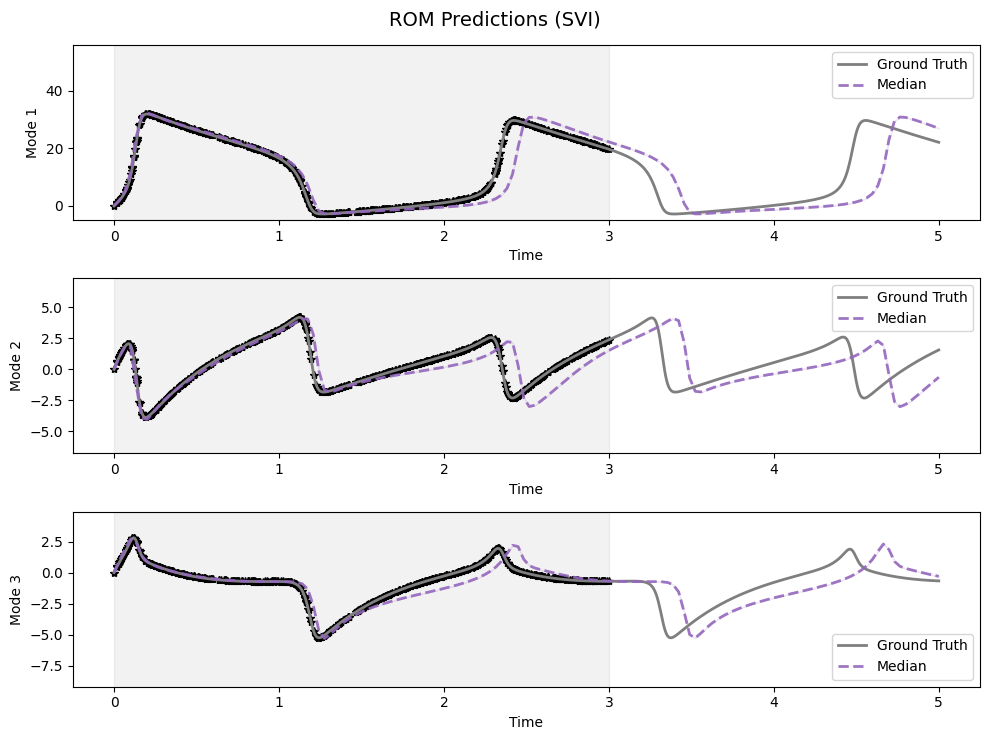

Stable ROM solves on prediction domain: 200


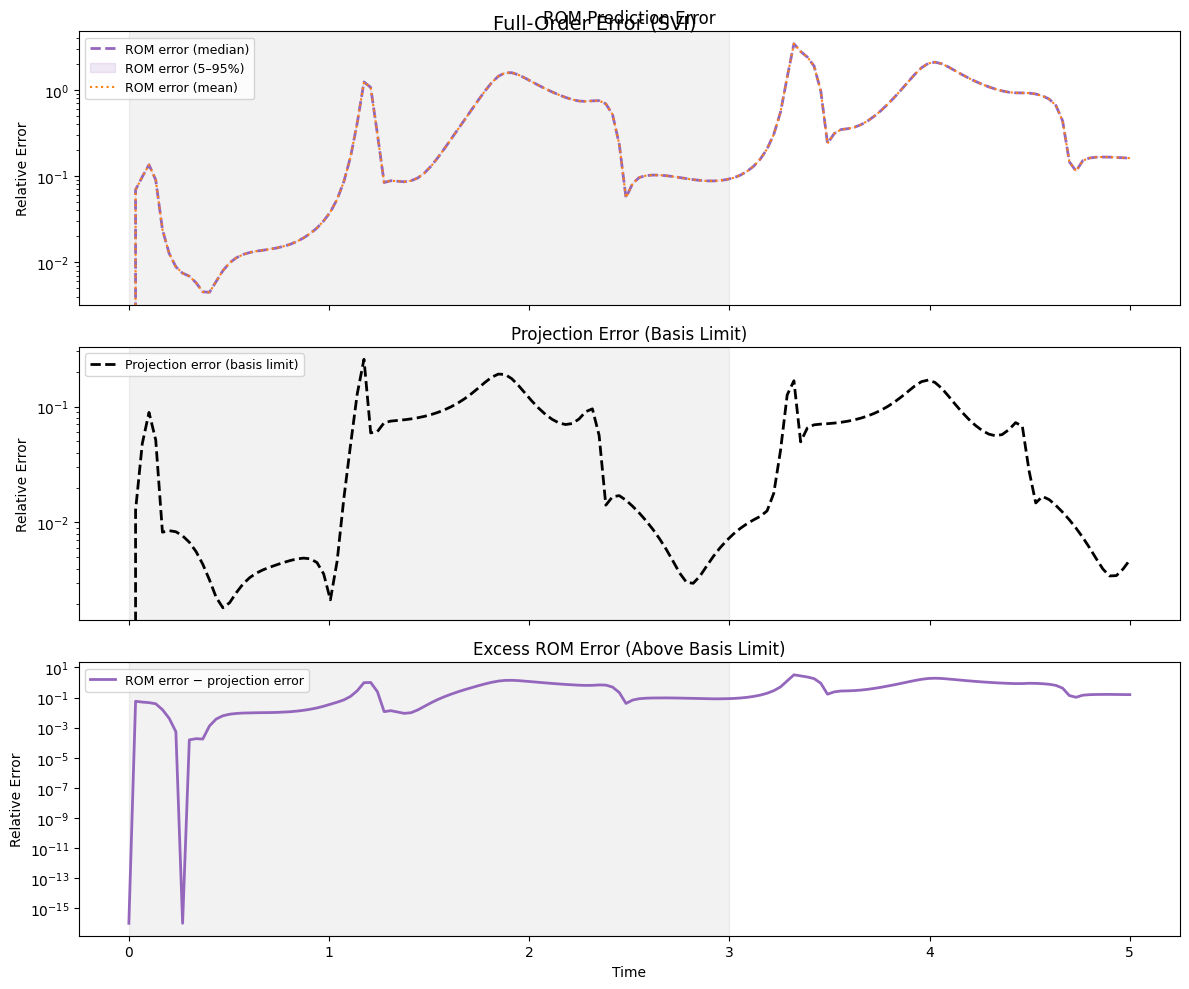

In [15]:
# === SVI Results ===
svi_start_time = time.time()

if RUN_SVI:
    svi_Os, svi_rom_solves = _evaluate_and_plot(svi_result.samples, "SVI")

total_plot_time += time.time() - svi_start_time

In [16]:
# Run MCMC (optional, more expensive)
if RUN_MCMC:
    # Initialize from SVI if requested and available
    init_values = None
    if USE_SVI_FOR_MCMC_INIT and RUN_SVI and 'svi_O_init' in dir() and svi_O_init is not None:
        init_values = {"O": svi_O_init}
        print(f"Initializing MCMC from SVI result (shape: {svi_O_init.shape})")
    else:
        print("MCMC will find its own starting point via NUTS adaptation")

    # Build shifted model or reuse SVI model
    if USE_SHIFTED_PRIOR_FOR_MCMC and RUN_SVI and 'svi_Os' in dir():
        mcmc_model = build_bayesian_opinf_model(
            prior_operator=jnp.zeros_like(prior_operator),
            rom=rom,
            Ls_means=Ls,
            Vs_means=Vs,
            time_domain_sampled=time_sampled,
            snapshots=training_data,
            Xs_means=Xs_means,
            Ns_means=Ns,
            inputs_eval=inputs_eval,
            data_scaler=data_scaler if USE_SCALED_DATA else None,
            reparam="shifted",
            svi_O_mean=svi_Os.mean(axis=0),
            svi_O_std=jnp.ones_like(svi_Os.mean(axis=0))*GAMMA3
        )
        print("Built shifted model: prior re-centered on SVI posterior")
    else:
        mcmc_model = bayesian_opinf_model
        print("Using original model for MCMC")

    mcmc_result = run_mcmc(
        model=mcmc_model,
        rng_key=jax.random.PRNGKey(1),
        time_eval=time_eval,
        init_values=init_values,
        gamma=GAMMA3 if GAMMA3 else GAMMA,
        gamma2=GAMMA4 if GAMMA4 else GAMMA2,
        num_warmup=150,
        num_samples=200,
        num_chains=2,
        verbose=VERBOSE
    )
    samples = mcmc_result.samples

Initializing MCMC from SVI result (shape: (3, 14))
Running MCMC (2 chains, 150 warmup, 200 samples)...


sample: 100%|██████████| 350/350 [03:39<00:00,  1.59it/s, 1023 steps of size 5.59e-03. acc. prob=0.94]

✅ MCMC complete! 400 samples collected.


In [17]:
# End time of the algorithm

end_time = time.time()
algo_time = end_time - start_time - total_plot_time

print(f"Total wall time: {end_time - start_time:.1f}s")
print(f"Plot time excluded: {total_plot_time:.1f}s")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

Total wall time: 877.4s
Plot time excluded: 46.6s
Algorithm runtime: 830.9s (13.8min)


### 5b. MCMC Results

[MCMC] Operator samples: 200, Stable solves: 200

MCMC Posterior mean (first row): [  56.25546   -121.120575   100.62932    103.16594      4.8276324]
MCMC Posterior std  (first row): [0.9016079  0.69900054 0.9529506  0.829846   0.02766875]
(200, 3, 14) (400, 3, 600)
(200, 3, 150) (200, 3, 150)


<Figure size 640x480 with 0 Axes>

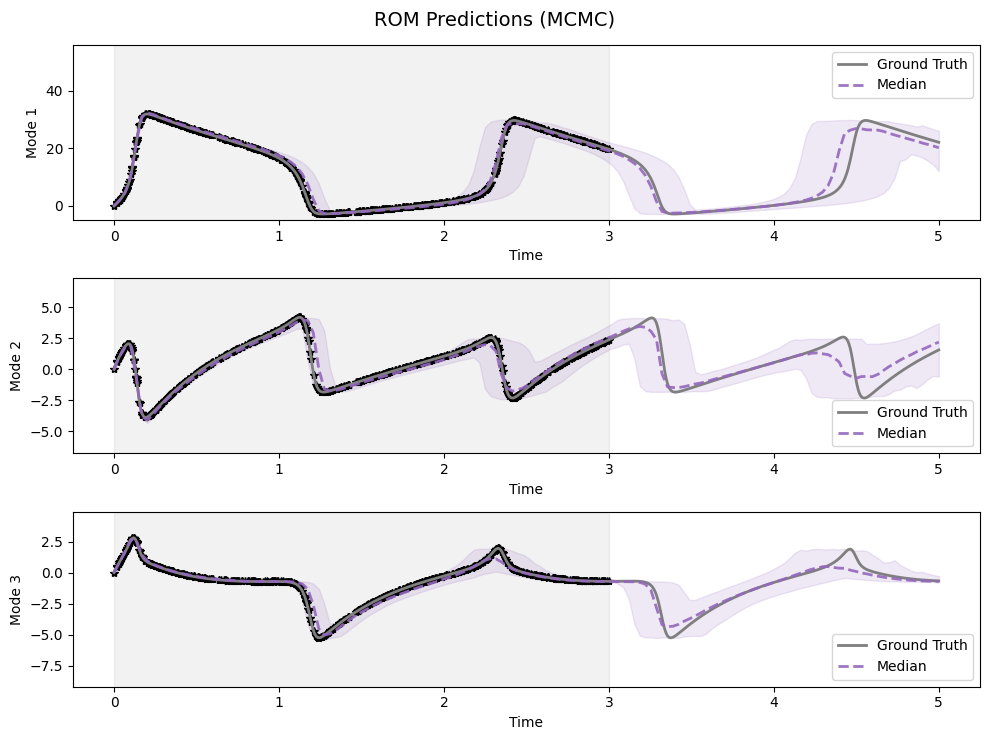

Stable ROM solves on prediction domain: 200


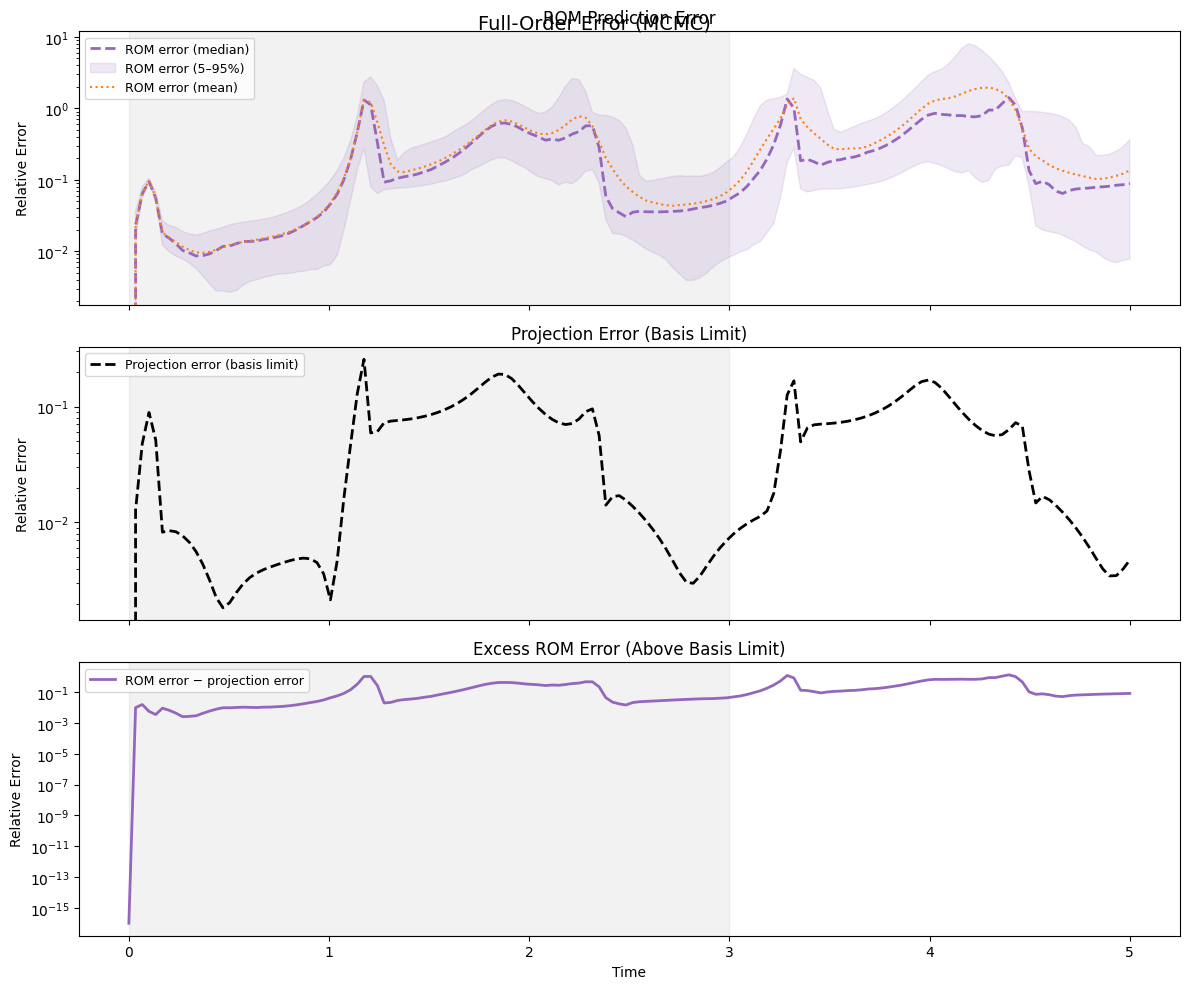

In [18]:
# === MCMC Results ===
_plot_t0 = time.time()
if RUN_MCMC:
    mcmc_Os, mcmc_rom_solves = _evaluate_and_plot(mcmc_result.samples, "MCMC")
total_plot_time += time.time() - _plot_t0

## 6. Summary

In [19]:
# Summary
print("=" * 50)
print("EXPERIMENT SUMMARY: FitzHugh-Nagumo")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Prior regularization: {result.best_reg:.1e}")
print(f"Prior error: {result.best_error:.4%}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
if RUN_SVI:
    print(f"\nSVI: {len(svi_Os)} operator samples, {len(svi_rom_solves)} stable solves")
if RUN_MCMC:
    print(f"MCMC: {len(mcmc_Os)} operator samples, {len(mcmc_rom_solves)} stable solves")

EXPERIMENT SUMMARY: FitzHugh-Nagumo
Operators: cAHBN
Modes: 3
Training span: [0, 3.0]
Prediction span: [0, 5.0]
Scaling: enabled
Prior regularization: 1.0e-08
Prior error: 48.1273%
Gamma (operator): 1.0
Gamma2 (ODE): 1.0
Guide: AutoDelta

SVI: 200 operator samples, 200 stable solves
MCMC: 200 operator samples, 200 stable solves


## 7. Bayesian Model Diagnostics

Run post-inference diagnostics to check for common pitfalls:
- **Posterior correlation** — highly correlated parameters suggest redundancy or non-identifiability
- **Effective sample size (ESS)** — low ESS means samples are highly autocorrelated
- **Prior-posterior overlap** — checks if data is actually informing the posterior
- **Trace plots** — visual check for mixing and stationarity
- **Divergences & R-hat** — MCMC-specific convergence checks (when applicable)

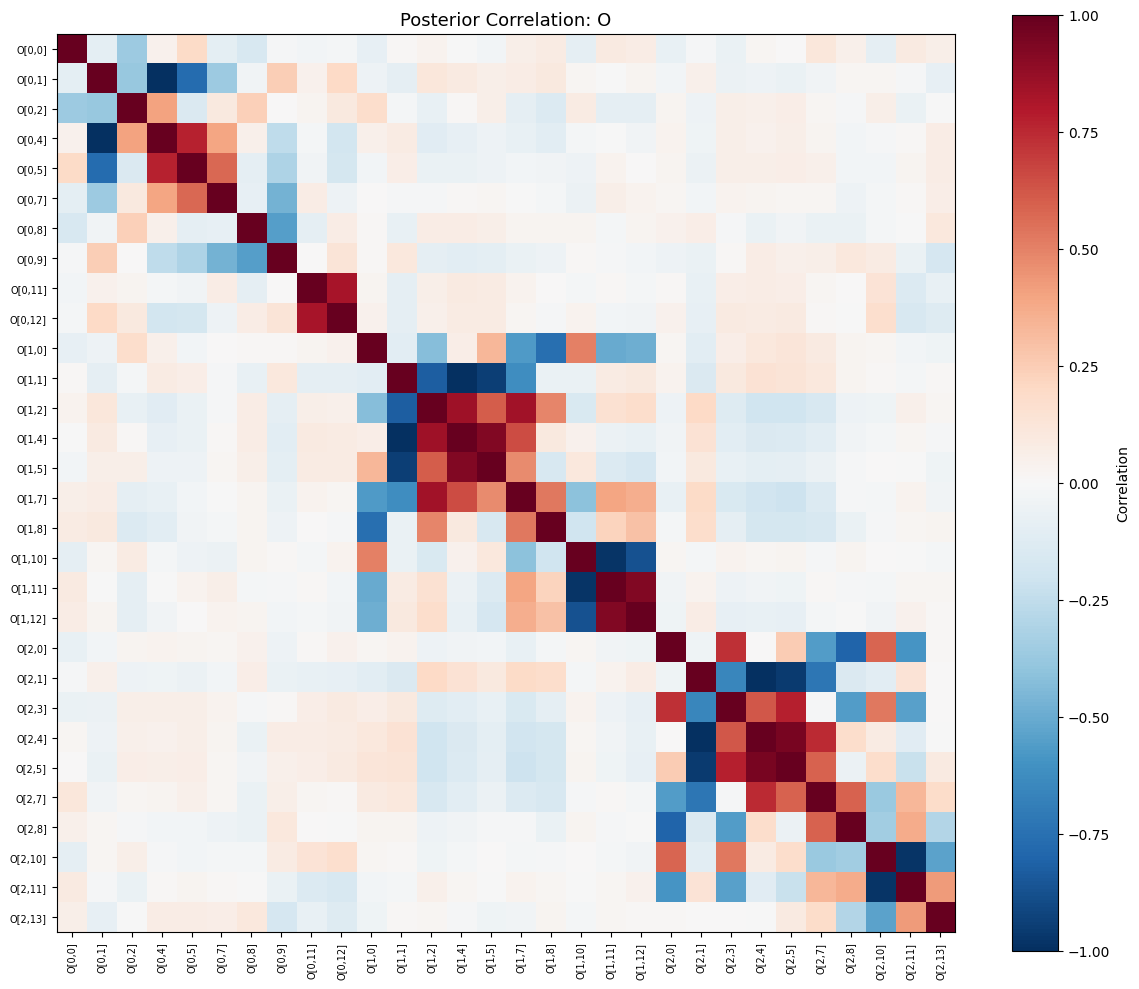

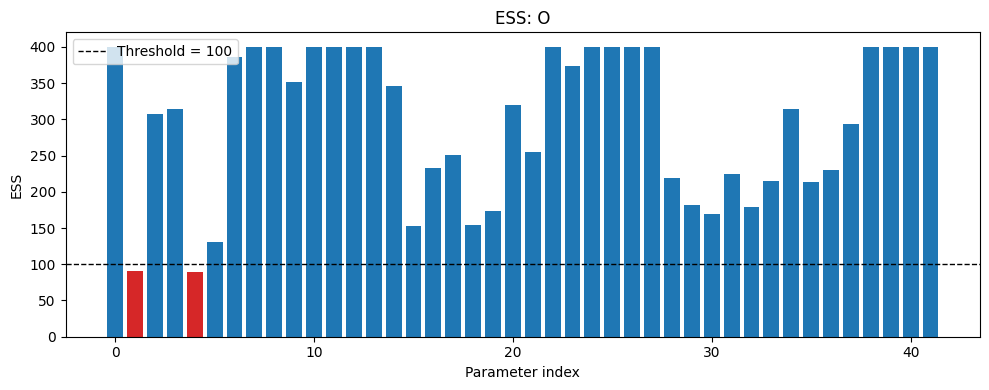

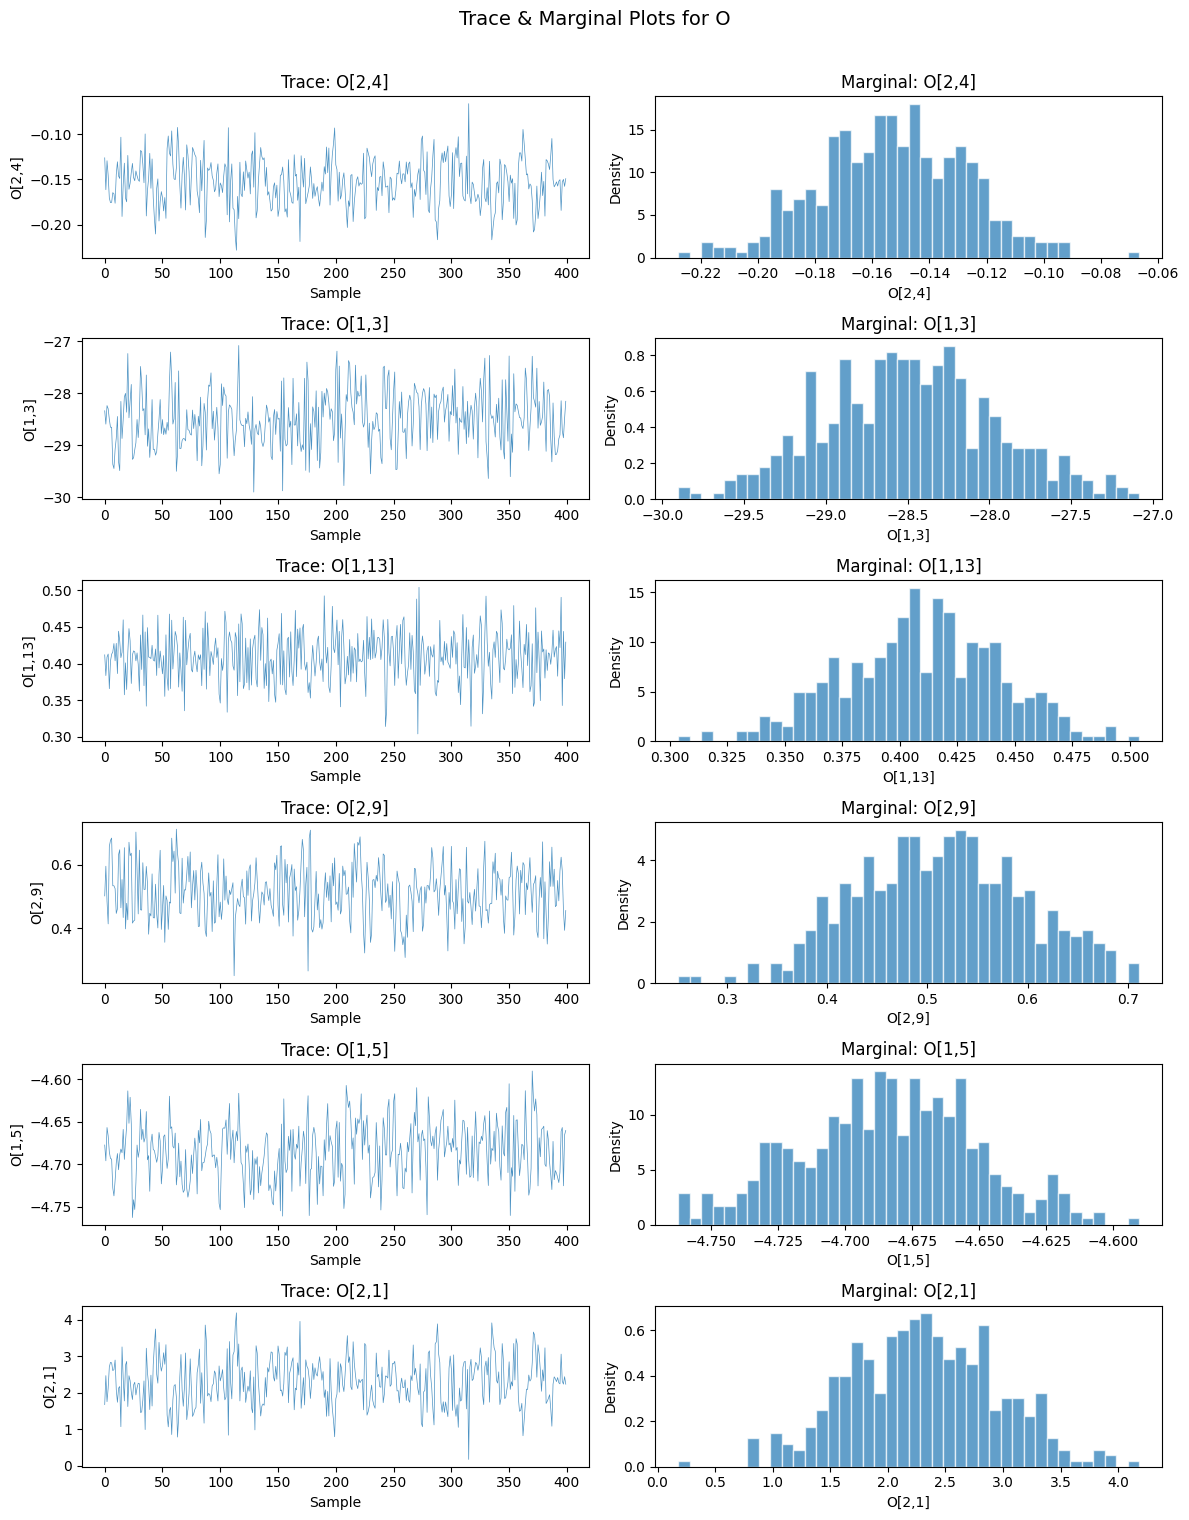

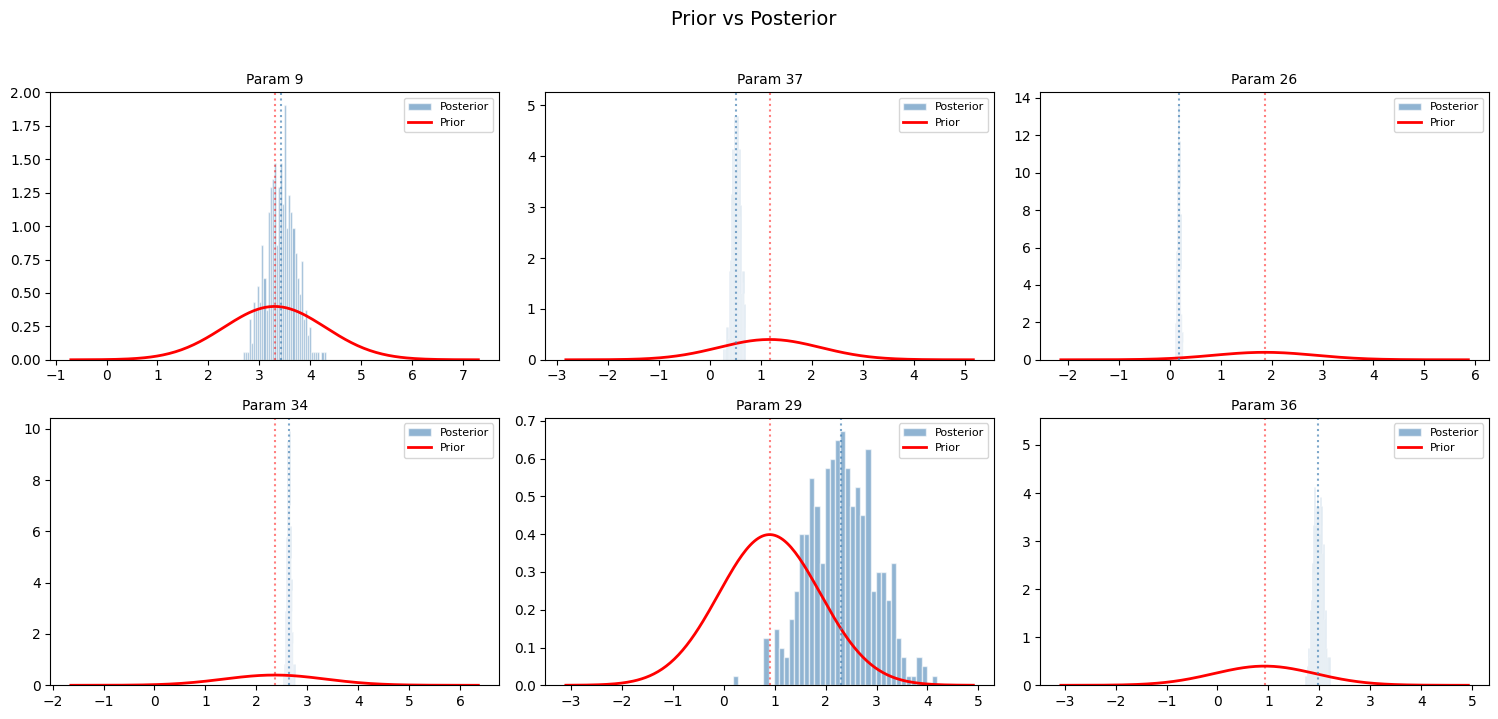

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  12 highly correlated pairs (|r| > 0.9):
    O[2,1] <-> O[2,4]: r = -0.999
    O[1,1] <-> O[1,4]: r = -0.999
    O[0,1] <-> O[0,4]: r = -0.997
    O[1,10] <-> O[1,11]: r = -0.984
    O[2,10] <-> O[2,11]: r = -0.981
    O[2,1] <-> O[2,5]: r = -0.958
    O[2,4] <-> O[2,5]: r = +0.950
    O[1,1] <-> O[1,5]: r = -0.939
    O[1,4] <-> O[1,5]: r = +0.929
    O[0,10] <-> O[0,11]: r = -0.928
    ... and 2 more

--- Effective Sample Size (ESS) ---
  Min ESS:  89.8
  Mean ESS: 299.3
  Max ESS:  400.0
    O[0,4]: ESS = 89.8
    O[0,1]: ESS = 91.0

--- MCMC Divergences ---
  Divergent transitions: 0
  Fraction: 0.00%

--- Prior-Posterior Overlap ---
  O[1,2]: overlap = 75.65% [OK]
  O[0,5]: overlap = 15.83% [OK]
  O[2,0]: overlap = 0.16% [CHECK]
  O[0,13]: overlap = 33.79% [OK]
  O[2,2]: overlap = 77.67% [OK]

--- Summary Warnings ---
  1. Found 12 highly correlated parameter pairs (|r| > 0.9). Consider reparameterization.
  2. 2 p

In [20]:
# Use MCMC samples if available, otherwise SVI
diag_samples = mcmc_result.samples if RUN_MCMC else svi_result.samples

# Run full diagnostic suite
diag_report = run_diagnostics(
    samples=diag_samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=mcmc_result if RUN_MCMC else None,
    samples_by_chain=None,
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=VERBOSE,
    plot=True,
)